In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df_entities = pd.read_parquet(
    "/content/drive/MyDrive/NLP_final_project/news_entities_notebook3.parquet",
    engine="pyarrow"
)

df_industries = df_entities.explode("industries").copy()
df_industries = df_industries[df_industries["industries"].notna()]

industry_summary = (
    df_industries.groupby("industries")
    .size()
    .reset_index(name="article_count")
    .sort_values("article_count", ascending=False)
)

industry_summary.head()

,industries,article_count
8,Media & Marketing,89912
10,Technology,78366
3,Finance,58027
1,Education,57106
4,Government & Public Sector,46673


In [5]:
industry_summary.to_csv(
    "/content/drive/MyDrive/NLP_final_project/industry_summary_notebook3.csv",
    index=False
)

print("saved industry_summary_notebook3.csv")

saved industry_summary_notebook3.csv


In [6]:
import pandas as pd

industry_summary = pd.read_csv("/content/drive/MyDrive/NLP_final_project/industry_summary_notebook3.csv")
company_summary = pd.read_csv("/content/drive/MyDrive/NLP_final_project/company_summary_notebook3.csv")
theme_summary = pd.read_csv("/content/drive/MyDrive/NLP_final_project/theme_summary_notebook4.csv")
sentiment_by_industry = pd.read_csv("/content/drive/MyDrive/NLP_final_project/sentiment_by_industry_notebook5.csv")
success_summary = pd.read_csv("/content/drive/MyDrive/NLP_final_project/success_summary_notebook6.csv")
barrier_summary = pd.read_csv("/content/drive/MyDrive/NLP_final_project/barrier_summary_notebook6.csv")

In [7]:
print(industry_summary.head())
print(company_summary.head())
print(theme_summary.head())
print(sentiment_by_industry.head())
print(success_summary.head())
print(barrier_summary.head())

                   industries  article_count
0           Media & Marketing          89912
1                  Technology          78366
2                     Finance          58027
3                   Education          57106
4  Government & Public Sector          46673
    org_entities  mention_count
0      Microsoft           5219
1         Google           5015
2         OpenAI           4227
3  Rawpixel Ltd.           4123
4     U.S. State           3478
                        impact_themes  article_count
0      Regulation / Governance / Risk          87620
1           Productivity / Efficiency          47907
2  Content Generation / Creative Work          28885
3  Customer Service / Personalization          27844
4                          Automation          27099
                           industries predicted_sentiment  article_count
0  Consulting & Professional Services            negative           3475
1  Consulting & Professional Services             neutral           7464
2

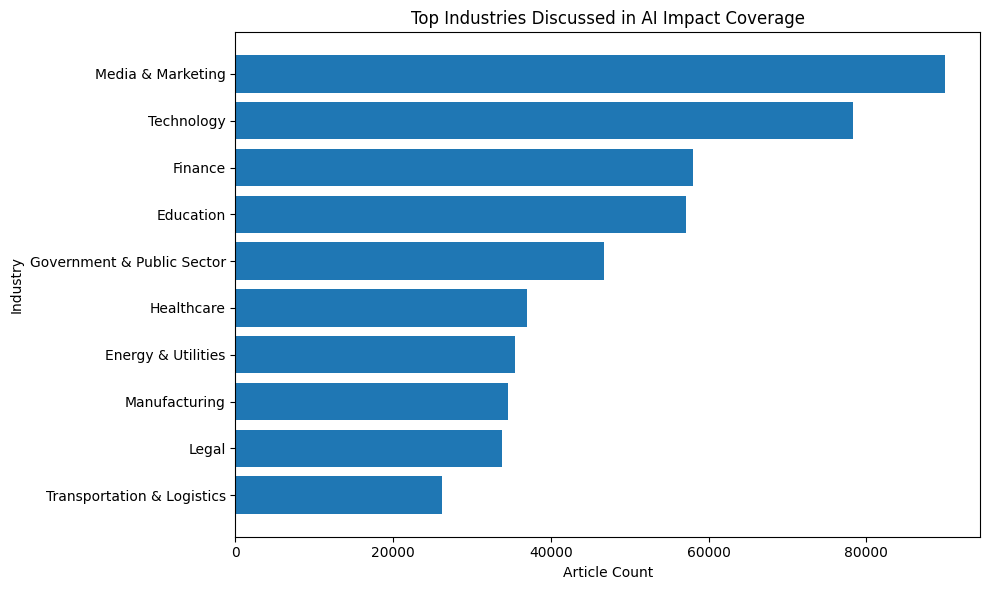

In [8]:
import matplotlib.pyplot as plt

top_industries = industry_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_industries["industries"][::-1], top_industries["article_count"][::-1])
plt.xlabel("Article Count")
plt.ylabel("Industry")
plt.title("Top Industries Discussed in AI Impact Coverage")
plt.tight_layout()
plt.show()

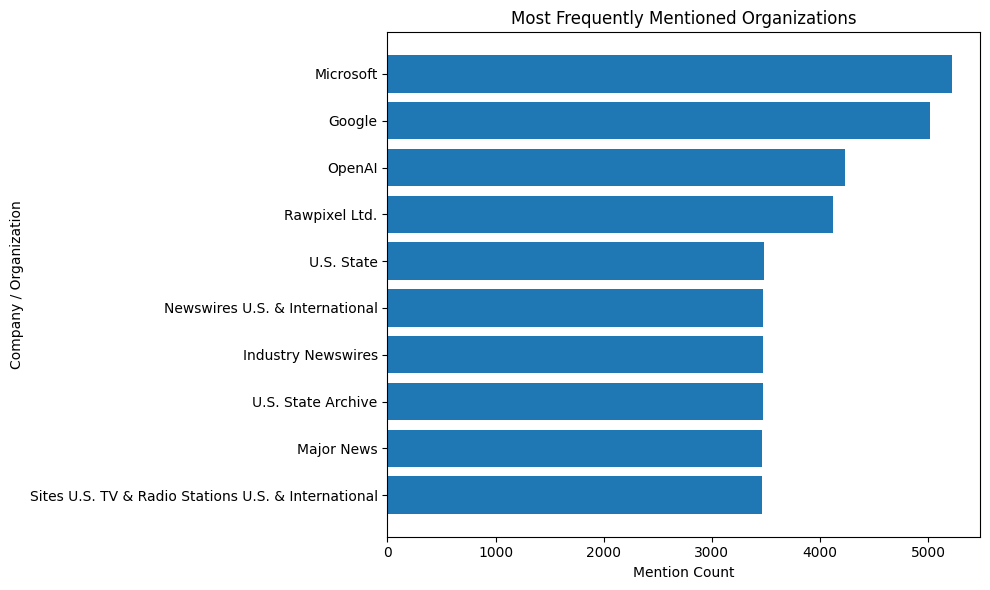

In [9]:
top_companies = company_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_companies["org_entities"][::-1], top_companies["mention_count"][::-1])
plt.xlabel("Mention Count")
plt.ylabel("Company / Organization")
plt.title("Most Frequently Mentioned Organizations")
plt.tight_layout()
plt.show()

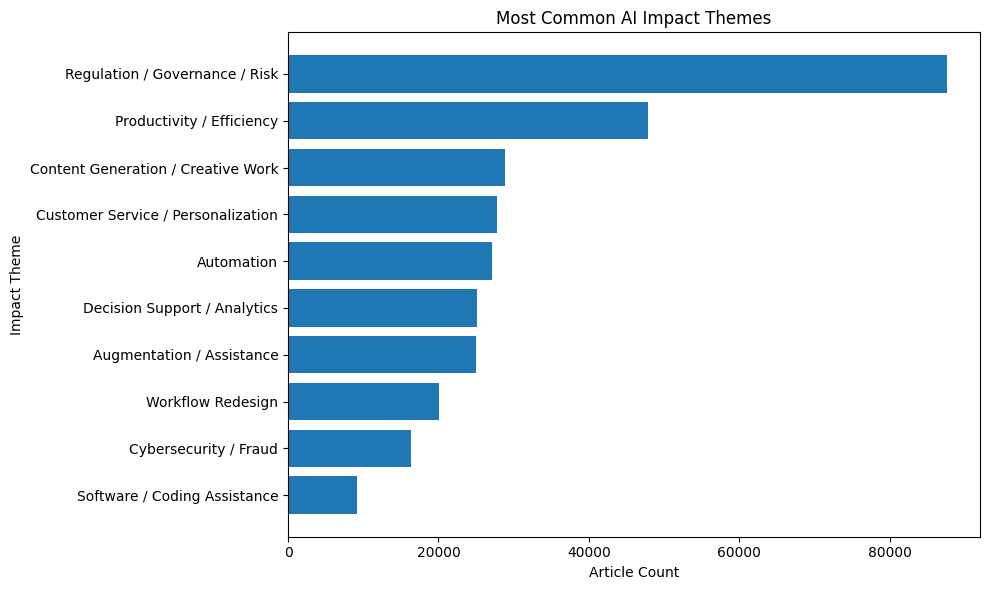

In [11]:
top_themes = theme_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_themes["impact_themes"][::-1], top_themes["article_count"][::-1])
plt.xlabel("Article Count")
plt.ylabel("Impact Theme")
plt.title("Most Common AI Impact Themes")
plt.tight_layout()
plt.show()

In [12]:
sentiment_pivot = sentiment_by_industry.pivot(
    index="industries",
    columns="predicted_sentiment",
    values="article_count"
).fillna(0)

sentiment_pivot

predicted_sentiment,negative,neutral,positive
industries,,,
Consulting & Professional Services,3475,7464,5267
Education,14540,24226,18340
Energy & Utilities,9368,13191,12832
Finance,15048,21491,21488
Government & Public Sector,14084,17971,14618
Healthcare,10274,13921,12769
Legal,10336,12823,10701
Manufacturing,7722,13035,13842
Media & Marketing,20481,37463,31968


In [13]:
sentiment_pct = sentiment_pivot.div(sentiment_pivot.sum(axis=1), axis=0)
sentiment_pct = sentiment_pct.sort_values(by="negative", ascending=False)

sentiment_pct.head(10)

predicted_sentiment,negative,neutral,positive
industries,,,
Legal,0.305257,0.378706,0.316037
Government & Public Sector,0.301759,0.385041,0.313200
Telecom,0.290082,0.399863,0.310055
Healthcare,0.277946,0.376610,0.345444
Retail & E-commerce,0.273988,0.357729,0.368282
Energy & Utilities,0.264700,0.372722,0.362578
Finance,0.259328,0.370362,0.370310
Education,0.254614,0.424229,0.321157
Transportation & Logistics,0.239837,0.403779,0.356384


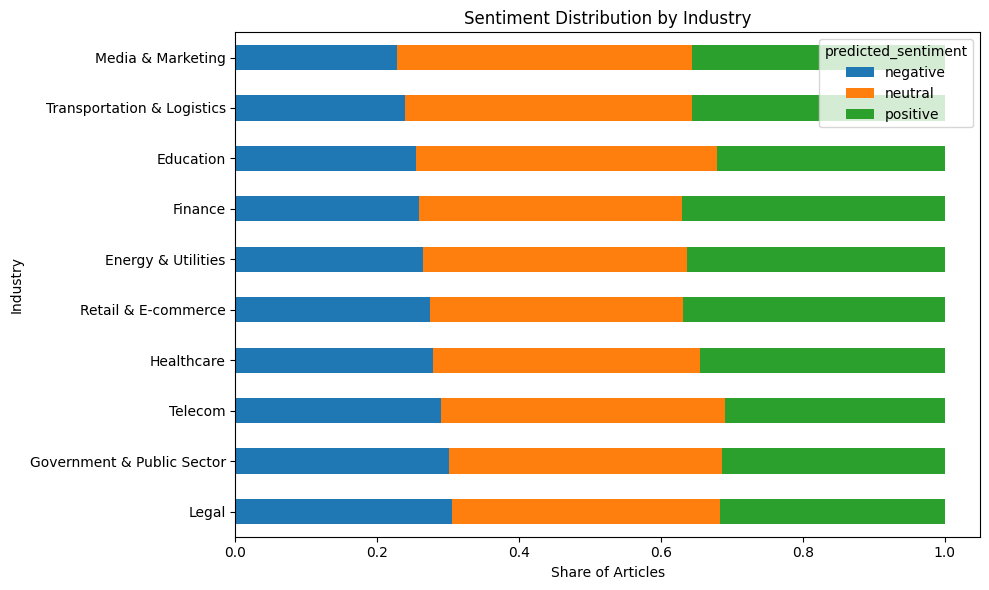

In [14]:
top_sentiment_industries = sentiment_pct.head(10)

top_sentiment_industries.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Share of Articles")
plt.ylabel("Industry")
plt.title("Sentiment Distribution by Industry")
plt.tight_layout()
plt.show()

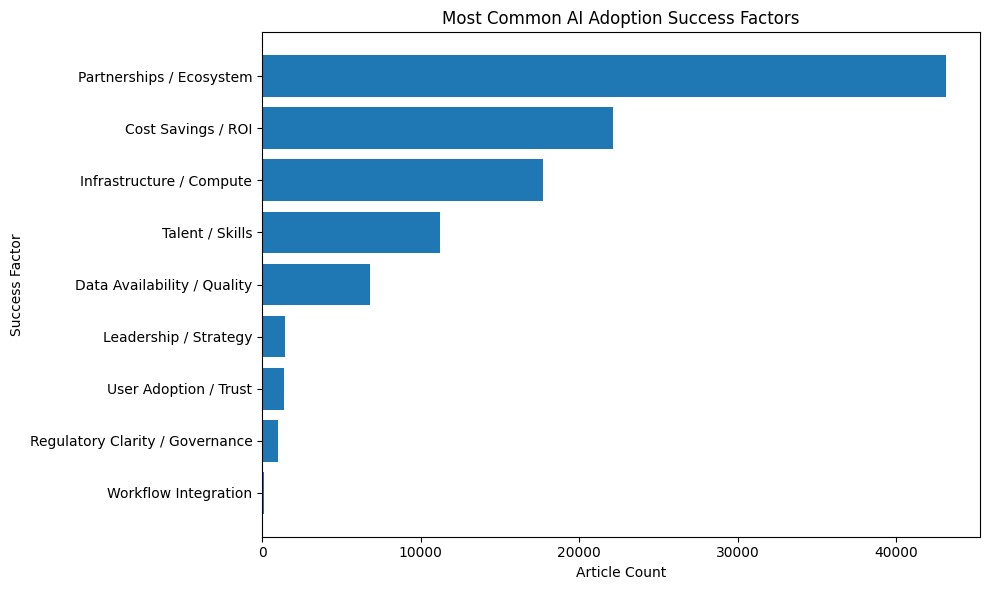

In [15]:
top_success = success_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_success["success_factors"][::-1], top_success["article_count"][::-1])
plt.xlabel("Article Count")
plt.ylabel("Success Factor")
plt.title("Most Common AI Adoption Success Factors")
plt.tight_layout()
plt.show()

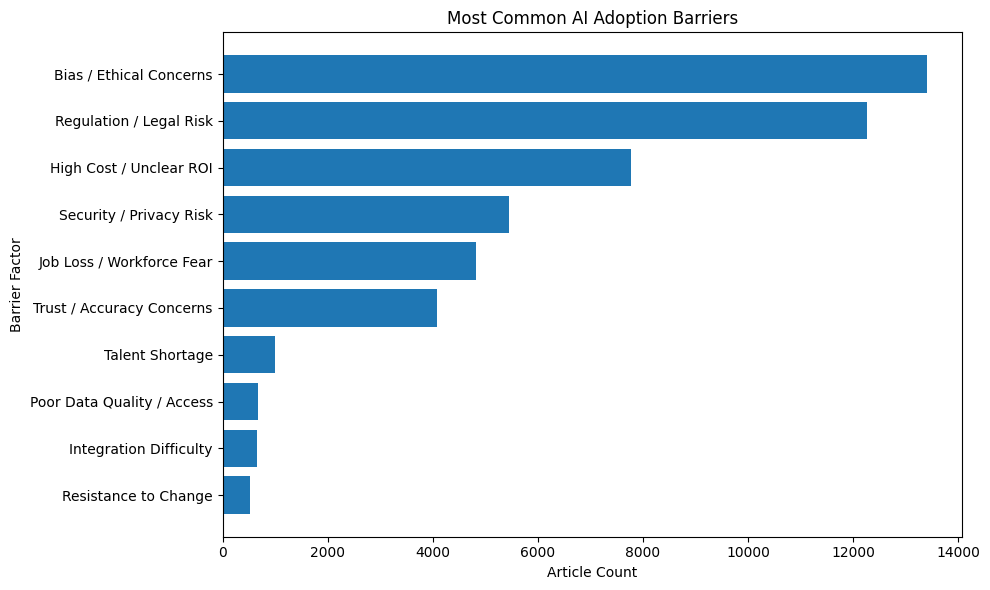

In [16]:
top_barriers = barrier_summary.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_barriers["barrier_factors"][::-1], top_barriers["article_count"][::-1])
plt.xlabel("Article Count")
plt.ylabel("Barrier Factor")
plt.title("Most Common AI Adoption Barriers")
plt.tight_layout()
plt.show()

In [17]:
final_top_industries = industry_summary.head(5).copy()
final_top_companies = company_summary.head(5).copy()
final_top_themes = theme_summary.head(5).copy()
final_top_success = success_summary.head(5).copy()
final_top_barriers = barrier_summary.head(5).copy()

print(final_top_industries)
print(final_top_companies)
print(final_top_themes)
print(final_top_success)
print(final_top_barriers)

                   industries  article_count
0           Media & Marketing          89912
1                  Technology          78366
2                     Finance          58027
3                   Education          57106
4  Government & Public Sector          46673
    org_entities  mention_count
0      Microsoft           5219
1         Google           5015
2         OpenAI           4227
3  Rawpixel Ltd.           4123
4     U.S. State           3478
                        impact_themes  article_count
0      Regulation / Governance / Risk          87620
1           Productivity / Efficiency          47907
2  Content Generation / Creative Work          28885
3  Customer Service / Personalization          27844
4                          Automation          27099
               success_factors  article_count
0     Partnerships / Ecosystem          43131
1           Cost Savings / ROI          22150
2     Infrastructure / Compute          17723
3              Talent / Skills      